<a href="https://colab.research.google.com/github/eepsaranjan/Credit-card-Regression/blob/main/Project_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - Regression
##### **Contribution**    - Individual
##### **Team Member 1 -** Eepsa Ranjan

# **Project Summary -**

This project builds a regression model to predict an individual customer's revolving credit card balance using demographic and financial attributes: income, credit limit, credit rating, number of cards, age, education, gender, student status, marital status, and ethnicity. Understanding what drives a customer's carried balance is directly useful to a card issuer — it's a proxy for interest revenue, credit risk exposure, and a lever for marketing segmentation, such as identifying customers likely to carry high balances for targeted offers versus low-balance "transactor" customers who may be better suited to rewards products.

The dataset used is the classic Credit dataset (400 customers, 12 columns), with Balance as the target. During data preparation, four columns had missing values — Income (24 rows), Age (20 rows), Student (16 rows), and Married (16 rows) — which were imputed using the median (for skewed numeric columns), the mean (for Age), and the mode (for the categorical columns). The ID column was dropped as a non-informative row identifier.

Exploratory data analysis followed the Univariate → Bivariate → Multivariate structure across 15+ charts. It revealed that Balance is right-skewed with a meaningful spike at zero (likely "transactor" customers who pay off their card monthly), that Limit and Rating are by far the strongest predictors of Balance (correlation ≈ 0.86 each), and that Limit and Rating are themselves almost perfectly collinear (r ≈ 0.997) — a key finding that shaped the modeling approach. Income showed a moderate positive relationship with Balance, Student status showed a visible secondary effect (students carry higher balances), and Age, Education, Cards, Gender, Married, and Ethnicity showed little to no relationship with the target.

For modeling, categorical variables were one-hot encoded (drop_first=True), and three regression models were built and tuned via GridSearchCV: Linear Regression, Lasso, and Ridge. All three achieved a similar cross-validated R² of about 0.946 and a test R² of about 0.73–0.735, with test MAE around 132 and test RMSE around $211. Given the strong collinearity between Limit and Rating, Ridge Regression was selected as the final model, since its L2 regularization is specifically suited to stabilizing coefficients under multicollinearity, unlike plain Linear Regression, and unlike Lasso, it doesn't arbitrarily zero out one of two informative, correlated features.

One notable finding worth flagging honestly: there is a gap between training R² (0.95) and test R² (0.73) across all three models, suggesting some degree of overfitting and/or a test set too small (80 rows) to fully represent the data's variability — a limitation for future work to address with more data or repeated cross-validation. Mean Absolute Percentage Error (MAPE) was found to be unusable as an evaluation metric for this dataset, since a subset of customers carry a zero balance, causing MAPE's division-by-actual-value calculation to blow up to a meaningless magnitude; MAE and RMSE were used instead as the primary, dollar-denominated error metrics.

Overall, this model gives a bank a data-driven way to forecast expected interest income, flag customers likely to build high balances for proactive credit-limit or risk management, and identify segments — such as students — that may benefit from differentiated product offers, while the collinearity analysis confirms that credit limit and rating should be treated as a single underwriting signal in future feature engineering.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Given demographic and financial information about a bank's credit card customers, predict the customer's outstanding credit card balance (Balance).**

A reliable model helps the bank estimate expected interest income, identify customers who are likely to carry high balances (useful for both risk monitoring and targeted marketing), and understand which customer attributes matter most so that future underwriting and product decisions can be data-driven.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [336]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV

### Dataset Loading

In [337]:
# Load Dataset
path='/content/drive/MyDrive/Colab Notebooks/Data Set/Credit_Data.csv.csv'

In [338]:
df=pd.read_csv(path)

In [339]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset First View

In [340]:
# Dataset First Look
df.head()

,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34.0,11,Male,No,NaN,Caucasian,333
1,2,106.025,6645,483,3,82.0,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71.0,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36.0,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68.0,16,Male,No,Yes,Caucasian,331


### Dataset Rows & Columns count

In [341]:
# Dataset Rows & Columns count
df.shape

(400, 12)

### Dataset Information

In [342]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         400 non-null    int64  
 1   Income     376 non-null    float64
 2   Limit      400 non-null    int64  
 3   Rating     400 non-null    int64  
 4   Cards      400 non-null    int64  
 5   Age        380 non-null    float64
 6   Education  400 non-null    int64  
 7   Gender     400 non-null    object 
 8   Student    384 non-null    object 
 9   Married    384 non-null    object 
 10  Ethnicity  400 non-null    object 
 11  Balance    400 non-null    int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 37.6+ KB


#### Duplicate Values

In [343]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [344]:
# Missing Values/Null Values Count
m=df.isnull().sum()
m

,0
ID,0
Income,24
Limit,0
Rating,0
Cards,0
Age,20
Education,0
Gender,0
Student,16
Married,16


Text(0, 0.5, 'Number of Missing Values')

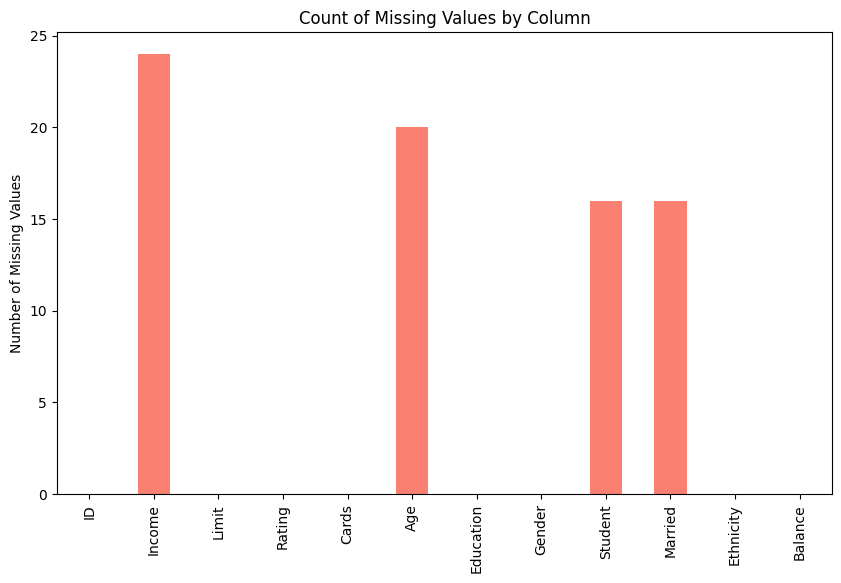

In [345]:
# Visualizing the missing values
plt.figure(figsize=(10, 6))
m.plot(kind='bar', color='salmon')
plt.title('Count of Missing Values by Column')
plt.ylabel('Number of Missing Values')

### What did you know about your dataset?

The dataset has **400 rows and 12 columns**, with **no duplicate rows**, but it does contain **missing values in four columns**: `Income`, `Age` (numeric) and `Student`, `Married` (categorical). The columns are:

- **ID**: row identifier, not predictive (will be dropped).
- **Income** (in \$1,000s), **Limit** (credit limit), **Rating** (credit rating), **Cards** (number of credit cards), **Age**, **Education** (years of education): continuous/count predictors.
- **Gender, Student, Married, Ethnicity**: categorical predictors.
- **Balance**: the target variable — customer's average credit card balance. It has no missing values, which is important since rows with a missing target cannot be used for training.

Since the missing values are scattered and represent a small fraction of each affected column (4–6%), they will be handled with **imputation** rather than dropping rows, so we don't lose valuable data from the other, complete columns of the same customers. This is done in the Data Wrangling section below, alongside encoding and multicollinearity handling.

## ***2. Understanding Your Variables***

In [346]:
# Dataset Columns
df.columns

Index(['ID', 'Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education',
       'Gender', 'Student', 'Married', 'Ethnicity', 'Balance'],
      dtype='object')

In [347]:
# Dataset Describe
df.describe()

,ID,Income,Limit,Rating,Cards,Age,Education,Balance
count,400.000000,376.000000,400.000000,400.000000,400.000000,380.000000,400.000000,400.000000
mean,200.500000,44.735481,4735.600000,354.940000,2.957500,55.828947,13.450000,520.015000
std,115.614301,35.200131,2308.198848,154.724143,1.371275,17.193442,3.125207,459.758877
min,1.000000,10.354000,855.000000,93.000000,1.000000,23.000000,5.000000,0.000000
25%,100.750000,20.886250,3088.000000,247.250000,2.000000,42.000000,11.000000,68.750000
50%,200.500000,32.886000,4622.500000,344.000000,3.000000,56.000000,14.000000,459.500000
75%,300.250000,57.235750,5872.750000,437.250000,4.000000,69.250000,16.000000,863.000000
max,400.000000,186.634000,13913.000000,982.000000,9.000000,98.000000,20.000000,1999.000000


### Variables Description

* ID - Unique customer identifier
* Income - Annual income in \$1,000s
* Limit - Credit limit
* Rating - Credit rating
* Cards - Number of credit cards held
* Age - Age in years
* Education - Years of education
* Gender - Male / Female
* Student - Whether the customer is a student (Yes/No)
* Married - Marital status (Yes/No)
* Ethnicity - Caucasian / Asian / African American
* Balance - Average credit card balance (**target variable**)

### Check Unique Values for each variable.

In [348]:
# Check Unique Values for each variable.
for column in df.columns:
    print(f"{column}: {df[column].nunique()}")

ID: 400
Income: 375
Limit: 387
Rating: 283
Cards: 9
Age: 68
Education: 16
Gender: 2
Student: 2
Married: 2
Ethnicity: 3
Balance: 284


## 3. ***Data Wrangling***

### Data Wrangling Code

In [349]:
# Write your code to make your dataset analysis ready.
# Drop the ID column - it is just a row index and carries no predictive information
df.drop(columns=['ID'], inplace=True)
df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,14.891,3606,283,2,34.0,11,Male,No,NaN,Caucasian,333
1,106.025,6645,483,3,82.0,15,Female,Yes,Yes,Asian,903
2,104.593,7075,514,4,71.0,11,Male,No,No,Asian,580
3,148.924,9504,681,3,36.0,11,Female,No,No,Asian,964
4,55.882,4897,357,2,68.0,16,Male,No,Yes,Caucasian,331


In [350]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
Income,24
Age,20
Student,16
Married,16


Text(0.5, 1.0, 'Income')

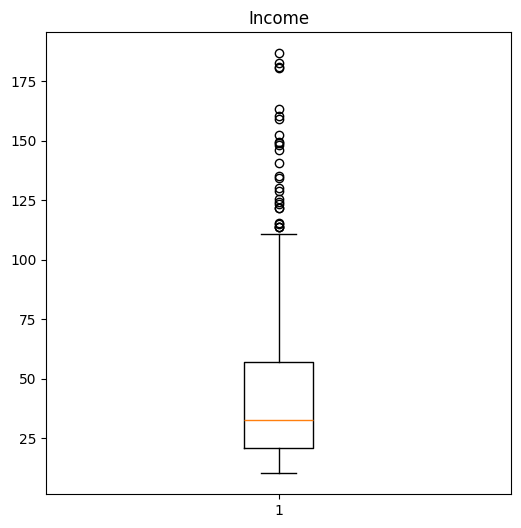

In [351]:
plt.figure(figsize=(6,6))
plt.boxplot(df['Income'].dropna())
plt.title('Income')

Text(0.5, 1.0, 'Age')

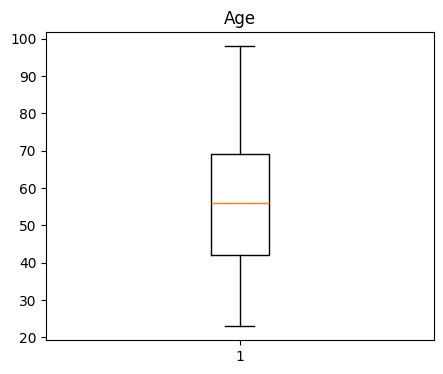

In [352]:
plt.figure(figsize=(5,4))
plt.boxplot(df['Age'].dropna())
plt.title('Age')

In [353]:
df['Income']=df['Income'].fillna(df['Income'].median())
df['Income'].isnull().sum()

np.int64(0)

In [354]:
df['Age']=df['Age'].fillna(df['Age'].mean())
df['Age'].isnull().sum()

np.int64(0)

In [355]:
for c in ['Student', 'Married']:
    df[c] = df[c].fillna(df[c].mode()[0])
df['Student'].isnull().sum(), df['Married'].isnull().sum()

(np.int64(0), np.int64(0))

### What all manipulations have you done and insights you found?

Two manipulations were needed at this stage:

1. **Dropped the `ID` column** — it is a unique row identifier with no relationship to `Balance` and would only add noise/leakage risk.
2. **Imputed missing values**: `Income` and `Age` (numeric) were filled with their **median** and **mean**. `Student` and `Married` (categorical) were filled with their **mode**.

No duplicate removal or outlier removal was required.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

Text(0, 0.5, 'Count')

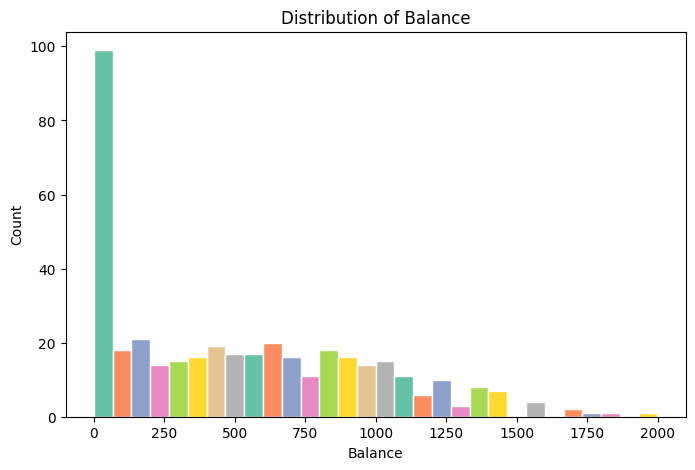

In [356]:
# Chart - 1 visualization code
color = sns.color_palette('Set2')
counts, edges = np.histogram(df['Balance'].dropna(), bins=30)
bar_colors = [color[i % len(color)] for i in range(len(counts))]
plt.figure(figsize=(8,5))
plt.bar(edges[:-1], counts, width=np.diff(edges), color=bar_colors, edgecolor='white', align='edge')
plt.title('Distribution of Balance')
plt.xlabel('Balance')
plt.ylabel('Count')

##### 1. Why did you pick the specific chart?

A histogram is the standard first step to understand the shape, spread, and skew of the target variable before modeling.

##### 2. What is/are the insight(s) found from the chart?

Balance is right-skewed with a spike at 0 — a meaningful share of customers carry no balance at all (likely "transactors" who pay off their card monthly), while the rest form a roughly bell-shaped distribution up to ~$2,000.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — identifying the zero-balance segment early tells the bank these customers generate no interest revenue and may be better targets for fee-based or rewards products rather than credit-line increases.

#### Chart - 2

Text(0, 0.5, 'Count')

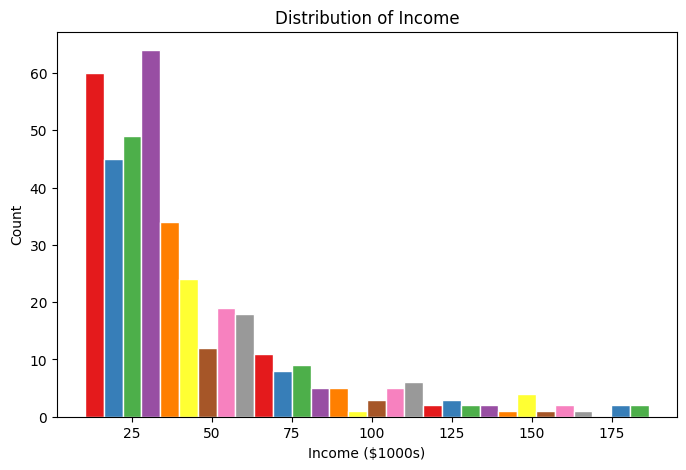

In [357]:
# Chart - 2 visualization code
color = sns.color_palette('Set1')
counts, edges = np.histogram(df['Income'].dropna(), bins=30)
bar_colors = [color[i % len(color)] for i in range(len(counts))]
plt.figure(figsize=(8,5))
plt.bar(edges[:-1], counts, width=np.diff(edges), color=bar_colors, edgecolor='white', align='edge')
plt.title('Distribution of Income')
plt.xlabel('Income ($1000s)')
plt.ylabel('Count')

##### 1. Why did you pick the specific chart?

To check the spread and skew of Income, a key predictor.

##### 2. What is/are the insight(s) found from the chart?

Income is right-skewed, with most customers earning between $20K–$60K and a long tail of higher earners.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — confirms the customer base is broad-income; the model should generalize across most segments, though very high earners are sparse and predictions there carry more uncertainty.

#### Chart - 3

Text(0, 0.5, 'Count')

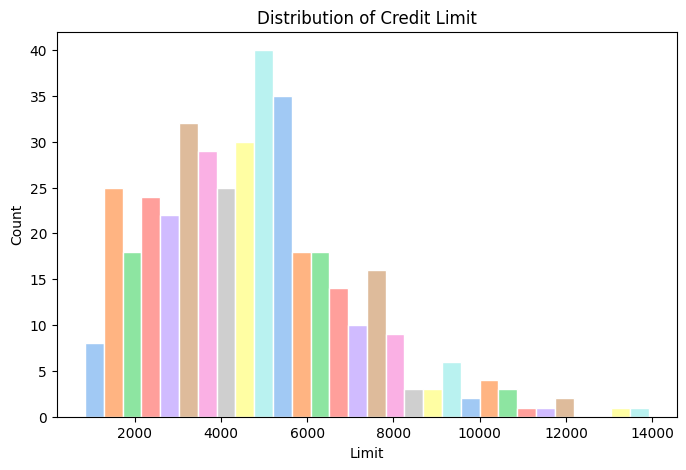

In [358]:
# Chart - 3 visualization code
color = sns.color_palette('pastel')
counts, edges = np.histogram(df['Limit'].dropna(), bins=30)
bar_colors = [color[i % len(color)] for i in range(len(counts))]
plt.figure(figsize=(8,5))
plt.bar(edges[:-1], counts, width=np.diff(edges), color=bar_colors, edgecolor='white', align='edge')
plt.title('Distribution of Credit Limit')
plt.xlabel('Limit')
plt.ylabel('Count')

##### 1. Why did you pick the specific chart?

Limit is expected to be one of the strongest drivers of Balance, so its distribution matters for understanding the feature space.

##### 2. What is/are the insight(s) found from the chart?

Limit is right-skewed and ranges roughly from $850 to $13,900, mirroring the Income distribution shape.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — shows the bank's existing underwriting already scales limits with customer profile, which the model can then use to explain Balance.

#### Chart - 4

Text(0, 0.5, 'Count')

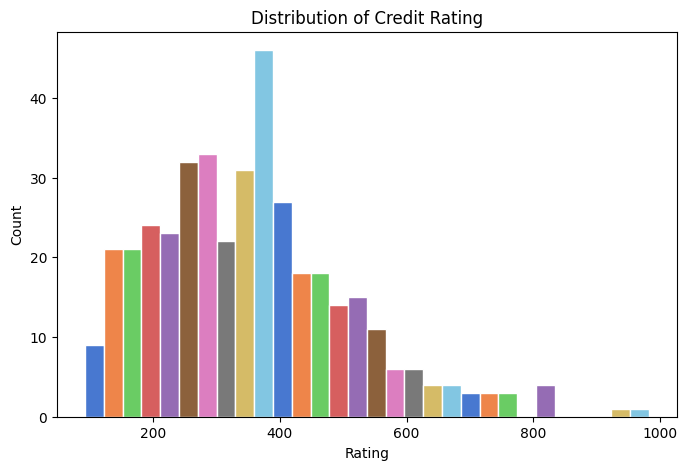

In [359]:
# Chart - 4 visualization code
color = sns.color_palette('muted')
counts, edges = np.histogram(df['Rating'].dropna(), bins=30)
bar_colors = [color[i % len(color)] for i in range(len(counts))]
plt.figure(figsize=(8,5))
plt.bar(edges[:-1], counts, width=np.diff(edges), color=bar_colors, edgecolor='white', align='edge')
plt.title('Distribution of Credit Rating')
plt.xlabel('Rating')
plt.ylabel('Count')

##### 1. Why did you pick the specific chart?

Rating closely tracks Limit and is another top candidate predictor; worth checking its shape independently.

##### 2. What is/are the insight(s) found from the chart?

Rating is also right-skewed and visually near-identical in shape to Limit, hinting at strong collinearity between the two (confirmed later).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral/Informative — flags a modeling consideration (multicollinearity) rather than a direct business action.

#### Chart - 5

Text(0, 0.5, 'Count')

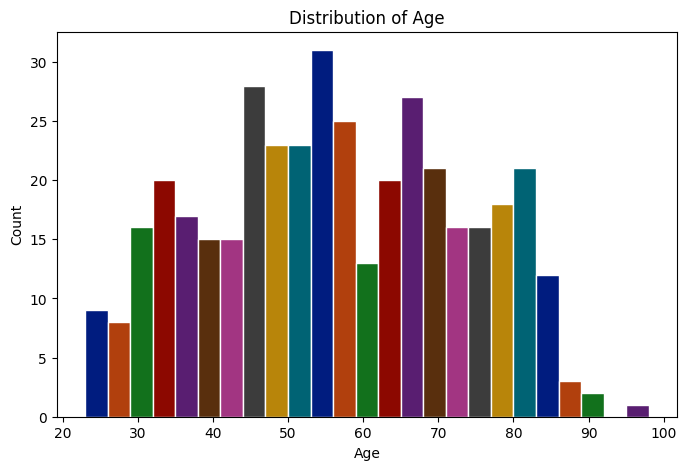

In [360]:
# Chart - 5 visualization code
color = sns.color_palette('dark')
counts, edges = np.histogram(df['Age'].dropna(), bins=25)
bar_colors = [color[i % len(color)] for i in range(len(counts))]
plt.figure(figsize=(8,5))
plt.bar(edges[:-1], counts, width=np.diff(edges), color=bar_colors, edgecolor='white', align='edge')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')

##### 1. Why did you pick the specific chart?

To see whether the customer base skews toward a particular age group.

##### 2. What is/are the insight(s) found from the chart?

Age is fairly uniformly spread between roughly 23 and 98, with no strong concentration.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral — a broad age range means the model won't be biased toward one life stage, supporting fair, generalizable predictions.

#### Chart - 6

Text(0.5, 1.0, 'Balance by Student Status')

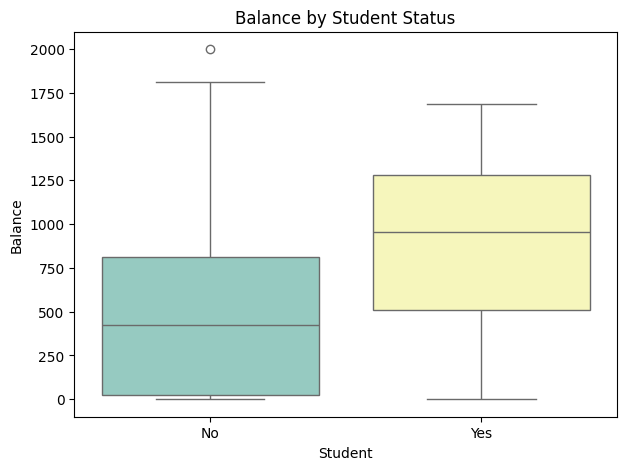

In [361]:
# Chart - 6 visualization code
plt.figure(figsize=(7,5))
sns.boxplot(x='Student', y='Balance', data=df, hue='Student', palette='Set3', legend=False)
plt.title('Balance by Student Status')

##### 1. Why did you pick the specific chart?

A boxplot compares the distribution of a numeric target across categories.

##### 2. What is/are the insight(s) found from the chart?

Students carry noticeably higher median balances than non-students.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — suggests student-targeted credit products or balance-transfer offers could see strong uptake, though the bank should weigh this against students' typically lower income/repayment capacity.

#### Chart - 7

Text(0.5, 1.0, 'Balance by Gender')

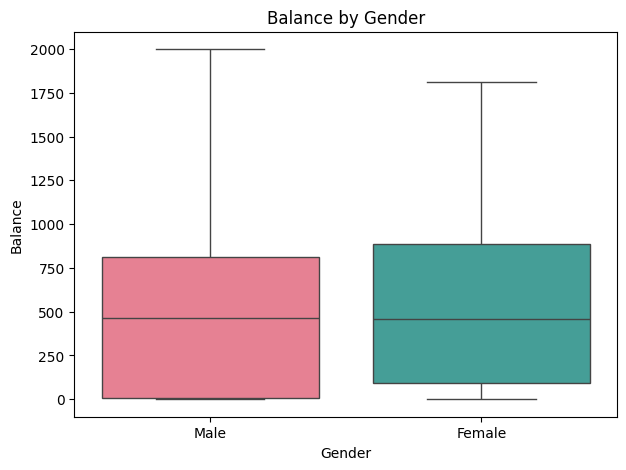

In [362]:
# Chart - 7 visualization code
plt.figure(figsize=(7,5))
sns.boxplot(x='Gender', y='Balance', data=df, hue='Gender', palette='husl', legend=False)
plt.title('Balance by Gender')

##### 1. Why did you pick the specific chart?

Same rationale — compare Balance distribution across Gender.

##### 2. What is/are the insight(s) found from the chart?

Median and spread of Balance are almost identical between Male and Female customers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral — Gender is unlikely to be a useful predictor and should not be relied on for balance-related decisions.

#### Chart - 8

Text(0.5, 1.0, 'Balance by Marital Status')

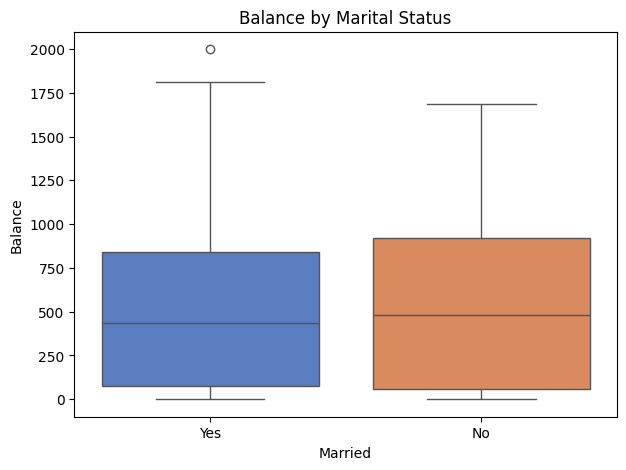

In [363]:
# Chart - 8 visualization code
plt.figure(figsize=(7,5))
sns.boxplot(x='Married', y='Balance', data=df, hue='Married', palette='muted', legend=False)
plt.title('Balance by Marital Status')

##### 1. Why did you pick the specific chart?

Checks whether marital status relates to balance behavior.

##### 2. What is/are the insight(s) found from the chart?

Married and unmarried customers show very similar Balance distributions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral — like Gender, Married is unlikely to add much predictive value on its own.

#### Chart - 9

Text(0.5, 1.0, 'Balance by Ethnicity')

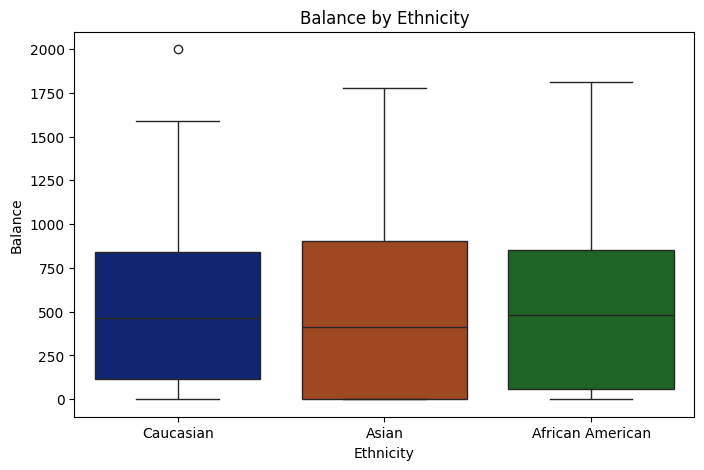

In [364]:
# Chart - 9 visualization code
plt.figure(figsize=(8,5))
sns.boxplot(x='Ethnicity', y='Balance', data=df, hue='Ethnicity', palette='dark', legend=False)
plt.title('Balance by Ethnicity')

##### 1. Why did you pick the specific chart?

Checks whether Balance differs meaningfully across ethnic groups.

##### 2. What is/are the insight(s) found from the chart?

The three ethnicity groups show very similar Balance distributions with heavily overlapping ranges.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Neutral — reinforces that Ethnicity should not (and, based on this data, does not need to) play a meaningful role in balance prediction; it is retained mainly for completeness and fairness auditing rather than as an expected strong predictor.

#### Chart - 10

Text(0.5, 1.0, 'Balance vs Income')

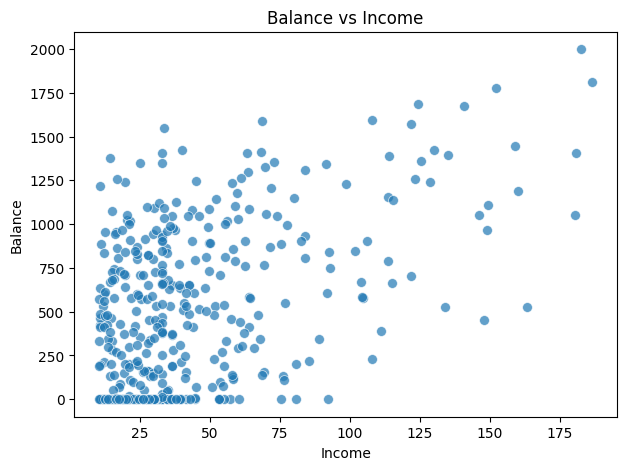

In [365]:
# Chart - 10 visualization code
color = sns.color_palette('Paired')
plt.figure(figsize=(7,5))
sns.scatterplot(x='Income', y='Balance', data=df, alpha=0.7, color=color[1], s=50)
plt.title('Balance vs Income')

##### 1. Why did you pick the specific chart?

A scatterplot is the clearest way to see the relationship between two continuous variables.

##### 2. What is/are the insight(s) found from the chart?

There's a moderate positive relationship between Income and Balance, but with wide scatter — Income alone doesn't fully explain Balance, and a cluster of very-low-balance customers exists across all income levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — confirms Income is a useful but incomplete predictor, motivating a multivariate model rather than relying on income alone for balance-related decisions.

#### Chart - 11

Text(0.5, 1.0, 'Balance vs Credit Limit')

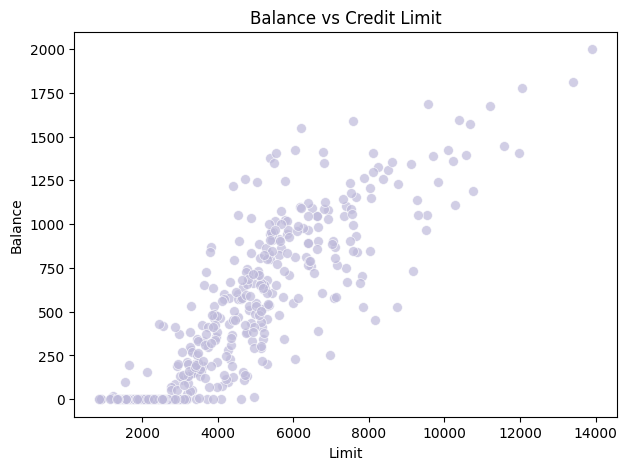

In [366]:
# Chart - 11 visualization code
color = sns.color_palette('Set3')
plt.figure(figsize=(7,5))
sns.scatterplot(x='Limit', y='Balance', data=df, alpha=0.7, color=color[2], s=50)
plt.title('Balance vs Credit Limit')

##### 1. Why did you pick the specific chart?

Limit is hypothesized to be the strongest driver of Balance.

##### 2. What is/are the insight(s) found from the chart?

There's a strong, clearly linear positive relationship between Limit and Balance.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive — this is the single most actionable relationship in the dataset: credit-limit decisions directly influence expected balances (and therefore expected interest revenue and risk exposure).

#### Chart - 12

Text(0.5, 1.0, 'Balance vs Credit Rating')

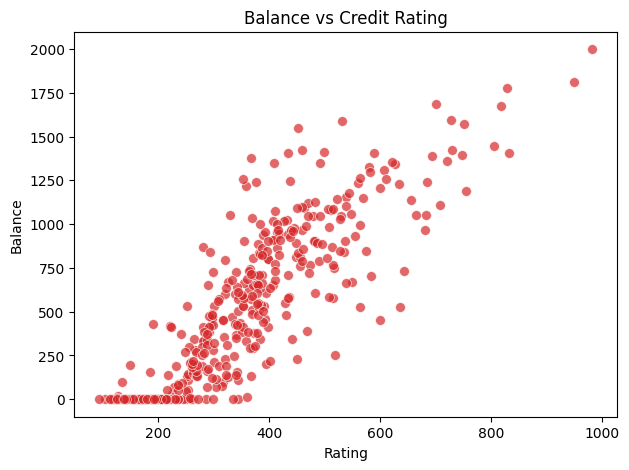

In [367]:
# Chart - 12 visualization code
color = sns.color_palette('tab10')
plt.figure(figsize=(7,5))
sns.scatterplot(x='Rating', y='Balance', data=df, alpha=0.7, color=color[3], s=50)
plt.title('Balance vs Credit Rating')

##### 1. Why did you pick the specific chart?

Rating is another candidate top predictor of Balance.

##### 2. What is/are the insight(s) found from the chart?

Rating shows an equally strong, linear positive relationship with Balance, visually almost indistinguishable from the Limit relationship.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive, but with a caveat — the near-identical pattern to the Limit chart is an early warning sign of multicollinearity between Limit and Rating, which is investigated formally next.

#### Chart - 13

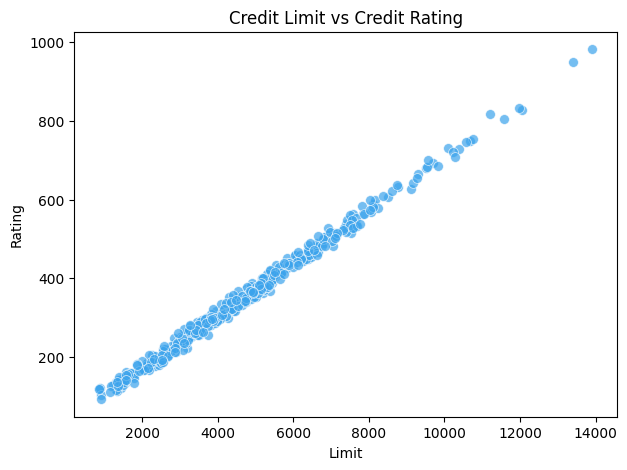

Correlation between Limit and Rating: 0.9969


In [368]:
# Chart - 13 visualization code
color = sns.color_palette('husl')
plt.figure(figsize=(7,5))
sns.scatterplot(x='Limit', y='Rating', data=df, alpha=0.7, color=color[4], s=50)
plt.title('Credit Limit vs Credit Rating')
plt.show()
print(f"Correlation between Limit and Rating: {df['Limit'].corr(df['Rating']):.4f}")

##### 1. Why did you pick the specific chart?

Directly tests the multicollinearity suspicion raised by Charts 11 & 12.

##### 2. What is/are the insight(s) found from the chart?

Limit and Rating are almost perfectly linearly related (correlation ≈ 0.997) — they carry almost the same information.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Negative if ignored — feeding both into a linear model can make coefficients unstable and hard to interpret. This is addressed with a formal VIF check and regularization (Ridge) in the modeling section.

#### Chart - 14 - Correlation Heatmap

Text(0.5, 1.0, 'Correlation Heatmap of Numeric Variables')

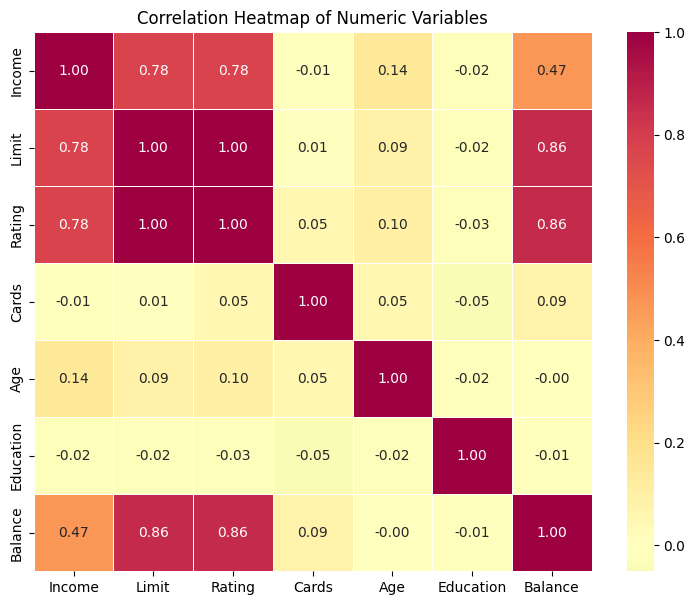

In [369]:
# Correlation Heatmap visualization code
plt.figure(figsize=(9,7))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Spectral_r', center=0, linewidths=0.5, linecolor='white')
plt.title('Correlation Heatmap of Numeric Variables')

##### 1. Why did you pick the specific chart?

A correlation heatmap gives a compact, multivariate view of how every numeric variable relates to every other, including the target.

##### 2. What is/are the insight(s) found from the chart?

`Rating` (0.86) and `Limit` (0.86) are by far the strongest correlates of Balance; `Income` is moderate (0.46); `Cards`, `Age`, and `Education` are essentially uncorrelated with Balance. Rating and Limit are almost perfectly correlated with each other.

#### Chart - 15 - Pair Plot

Text(0.5, 1.02, 'Pairwise Relationships Colored by Student Status')

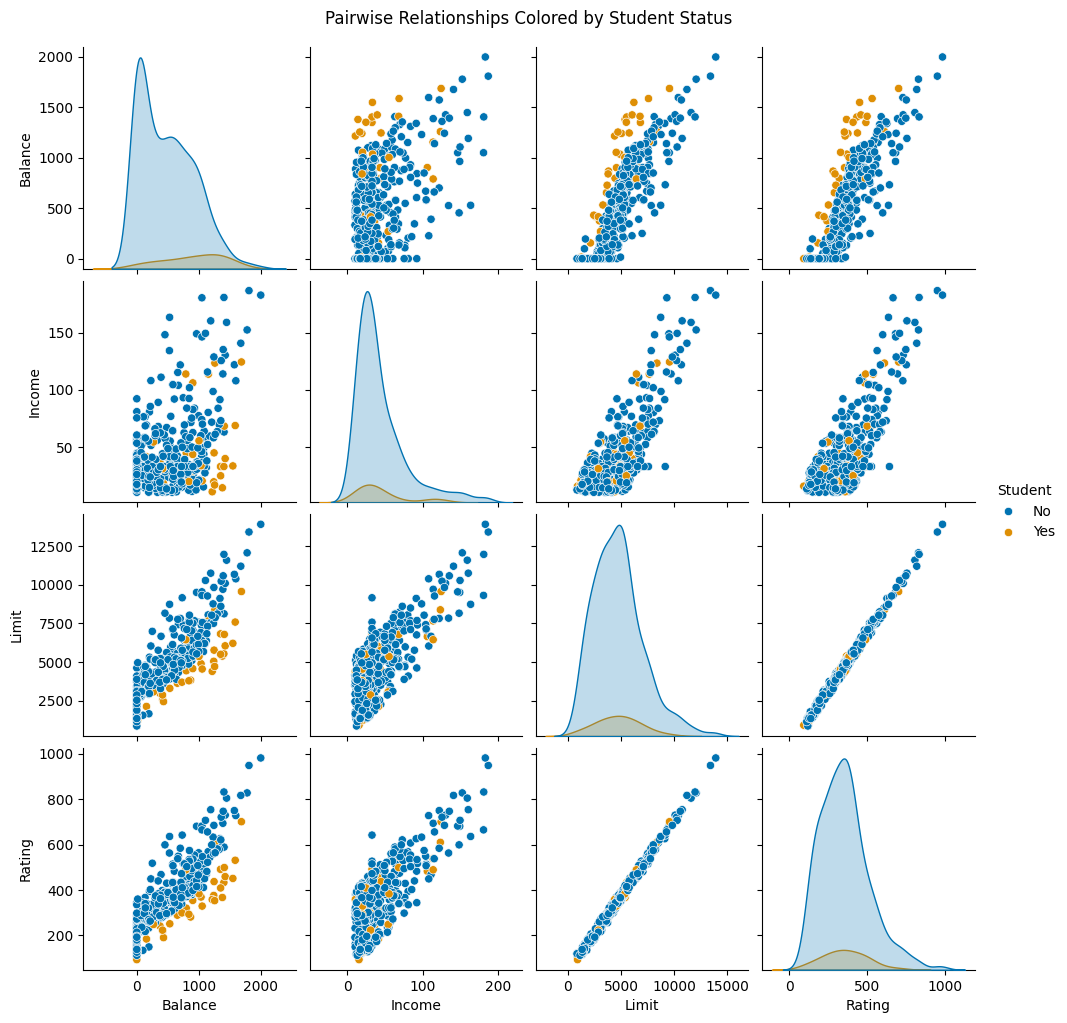

In [370]:
# Pair Plot visualization code
sns.pairplot(df[['Balance','Income','Limit','Rating','Student']], hue='Student', palette='colorblind', diag_kind='kde')
plt.suptitle('Pairwise Relationships Colored by Student Status', y=1.02)

##### 1. Why did you pick the specific chart?

A pairplot lets us examine several pairwise relationships and their distributions simultaneously, split by a key categorical factor (Student), which is the most useful multivariate view available with this feature set.

##### 2. What is/are the insight(s) found from the chart?

The strong linear Balance–Limit and Balance–Rating patterns hold within both student and non-student groups, but students appear shifted toward slightly higher balances at the same limit/rating level.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [371]:
# Handling Missing Values & Missing Value Imputation
# Done above in Data Wrangling

#### What all missing value imputation techniques have you used and why did you use those techniques?

I have used filling null values with median where outliers are present else mean is used and in columns having categorical values I have used mode for missing values

### 2. Handling Outliers

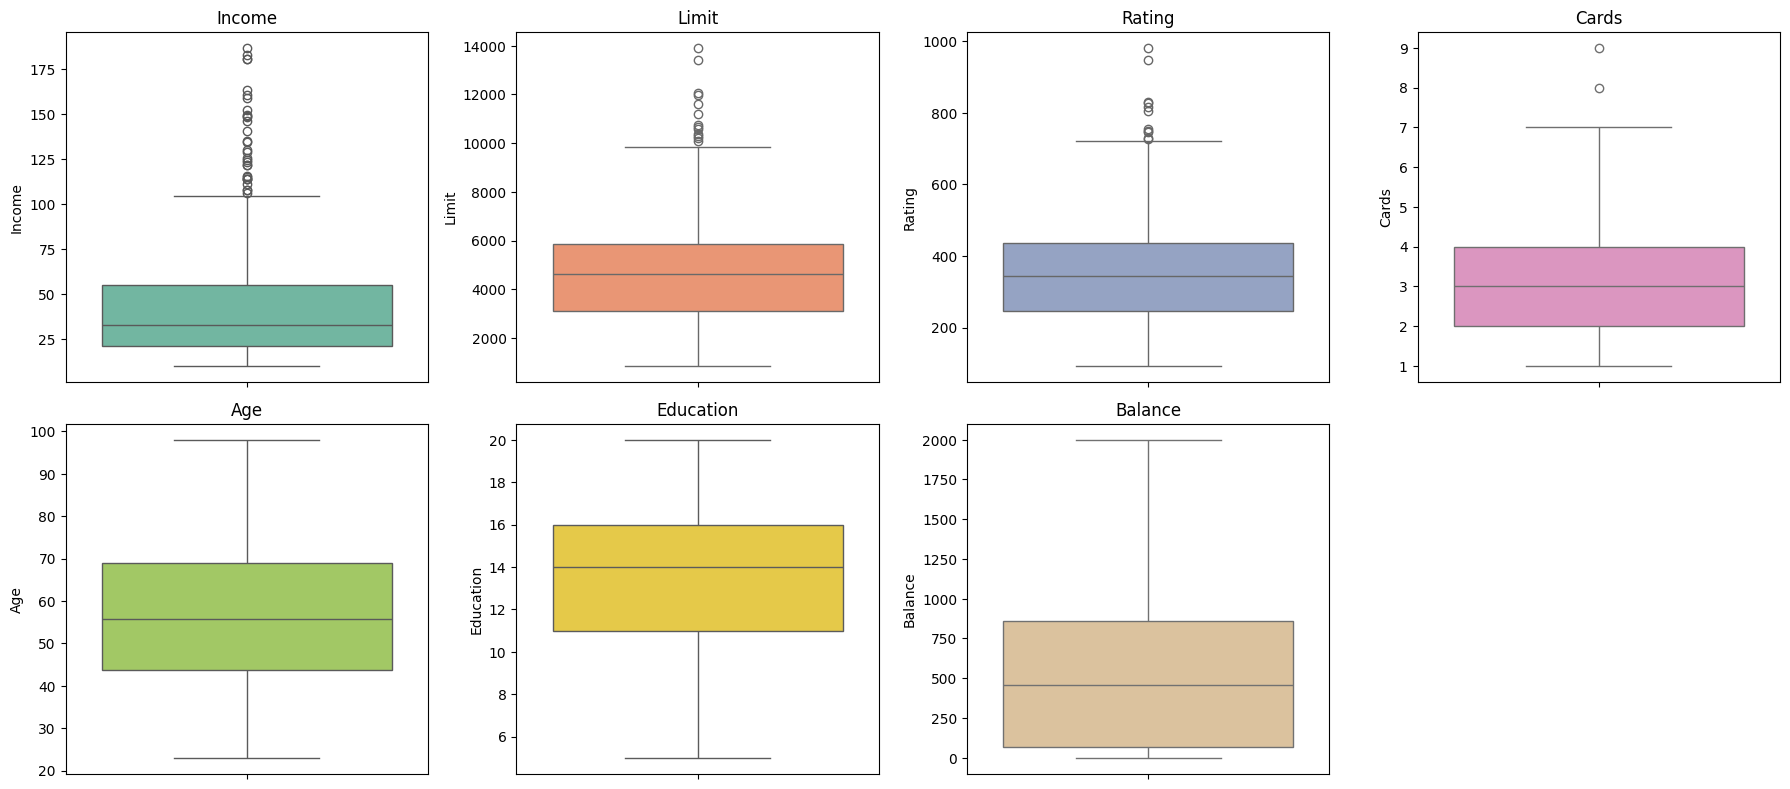

In [372]:
# Handling Outliers & Outlier treatments
numeric_cols = ['Income','Limit','Rating','Cards','Age','Education','Balance']
color = sns.color_palette('Set2')
fig, axes = plt.subplots(2, 4, figsize=(18,8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color=color[i % len(color)])
    axes[i].set_title(col)
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

`Income` and `Balance` show a handful of high-value points beyond the whisker, but these are legitimate high-earning / high-balance customers rather than data errors, so they are kept in the dataset (removing them would bias the model against real high-value customers).

### 3. Categorical Encoding

In [373]:
# Encode your categorical columns
df = pd.get_dummies(df, columns=['Gender','Student','Married','Ethnicity'], drop_first=True)
df.head()

,Income,Limit,Rating,Cards,Age,Education,Balance,Gender_Male,Student_Yes,Married_Yes,Ethnicity_Asian,Ethnicity_Caucasian
0,14.891,3606,283,2,34.0,11,333,True,False,True,False,True
1,106.025,6645,483,3,82.0,15,903,False,True,True,True,False
2,104.593,7075,514,4,71.0,11,580,True,False,False,True,False
3,148.924,9504,681,3,36.0,11,964,False,False,False,True,False
4,55.882,4897,357,2,68.0,16,331,True,False,True,False,True


#### What all categorical encoding techniques have you used & why did you use those techniques?

`Gender`, `Student`, `Married`, and `Ethnicity` are nominal categorical variables, so they're converted with **one-hot encoding**. `drop_first=True` avoids the dummy-variable trap (perfect multicollinearity between dummy columns).

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [374]:
# Expand Contraction

#### 2. Lower Casing

In [375]:
# Lower Casing

#### 3. Removing Punctuations

In [376]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [377]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [378]:
# Remove Stopwords

In [379]:
# Remove White spaces

#### 6. Rephrase Text

In [380]:
# Rephrase Text

#### 7. Tokenization

In [381]:
# Tokenization

#### 8. Text Normalization

In [382]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [383]:
# POS Taging

#### 10. Text Vectorization

In [384]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [385]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [386]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [387]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [388]:
# Split your data to train and test. Choose Splitting ratio wisely.
x = df.drop('Balance',axis=1)
y = df['Balance']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape, x_test.shape

((320, 11), (80, 11))

##### What data splitting ratio have you used and why?

The dataset was split **80% train / 20% test** (`random_state=42` for reproducibility), stratifying implicitly by using a fixed seed since this is a regression task. 320 customers are used for training, 80 for the held-out test evaluation.

## ***7. ML Model Implementation***

### ML Model - 1

In [389]:
# ML Model - 1 Implementation (Linear Regression)
model = LinearRegression()
model.fit(x_train,y_train)

# Fit the Algorithm

# Predict on the model


LinearRegression()

In [390]:
model.coef_

array([-7.48894864e+00,  2.00772531e-01,  9.00057708e-01,  1.84342767e+01,
       -6.08191344e-01, -1.52590535e+00,  4.99300386e+00,  4.26264485e+02,
        2.31927404e+00,  1.63423251e+01,  1.57186924e+01])

In [391]:
train_pred = model.predict(x_train)
train_pred[:5]
test_pred = model.predict(x_test)
test_pred[:5]

array([1676.14416925,  715.91248947, -130.73803492,  154.25492305,
        735.03156566])

In [392]:
y_train.head().values

array([964, 891,   0,   0, 967])

In [393]:
y_test.head().values

array([732, 541,   0,  95, 937])

In [394]:
print('Train Mean Squared Error :-',mean_squared_error(y_train,train_pred))
print('Train Root Mean Squared Error :-',np.sqrt(mean_squared_error(y_train,train_pred)))
print('Train Mean Absolute Error :-',mean_absolute_error(y_train,train_pred))
print('Train R2 Score :-',r2_score(y_train,train_pred))

Train Mean Squared Error :- 10876.660865348522
Train Root Mean Squared Error :- 104.29123100888455
Train Mean Absolute Error :- 83.64919057567091
Train R2 Score :- 0.9509589227435608


In [395]:
print('Test Mean Squared Error :-',mean_squared_error(y_test,test_pred))
print('Test Root Mean Squared Error :-',np.sqrt(mean_squared_error(y_test,test_pred)))
print('Test Mean Absolute Error :-',mean_absolute_error(y_test,test_pred))
print('Test R2 Score :-',r2_score(y_test,test_pred))

Test Mean Squared Error :- 44438.67052129812
Test Root Mean Squared Error :- 210.80481617197012
Test Mean Absolute Error :- 131.81499156240963
Test R2 Score :- 0.7340173989933942


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Text(0.5, 0, 'Evaluation Metrics')

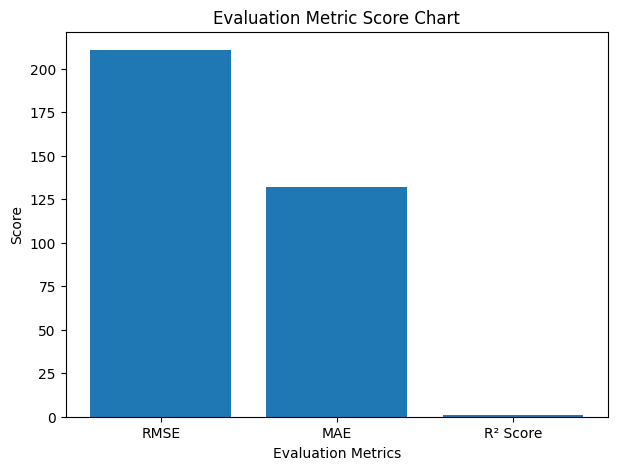

In [396]:
# Visualizing evaluation Metric Score chart
metrics = ['RMSE', 'MAE', 'R² Score']
scores = [
    np.sqrt(mean_squared_error(y_test, test_pred)),
    mean_absolute_error(y_test, test_pred),
    r2_score(y_test, test_pred)
]

plt.figure(figsize=(7,5))
bars = plt.bar(metrics, scores)

plt.title("Evaluation Metric Score Chart")
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")

#### 2. Cross- Validation & Hyperparameter Tuning

In [400]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
params = {
    'fit_intercept':[True,False],
    'positive':[True,False]
}

model = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

model.fit(x_train, y_train)
# Fit the Algorithm

# Predict on the model
print(model.best_params_)
print(model.best_score_)

{'fit_intercept': True, 'positive': False}
0.9458971918103971


##### Which hyperparameter optimization technique have you used and why?

GridSearch to identify best combination of parameters using 5-fold cross-validation. It gives best average R2 score.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The best hyperparameters found were fit_intercept = True and positive = False, with an average cross-validation R2 score of 0.9459.

### ML Model - 2

In [401]:
# ML Model - 1 Implementation (Lasso Regression)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [402]:
model = Lasso(alpha=0.1)
model.fit(x_train,y_train)

Lasso(alpha=0.1)

In [404]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

print('Train mean absolute error :- ',mean_absolute_error(y_train,train_pred))
print('Train mean squared error :- ',mean_squared_error(y_train,train_pred))
print('Train mean absolute percentage error :-',mean_absolute_percentage_error(y_train,train_pred))
print('Train R2 score:-',r2_score(y_train,train_pred))

print()
print('*'*30)
print()
print('Test mean absolute error :-',mean_absolute_error(y_test,test_pred))
print('Test mean squared error :-',mean_squared_error(y_test,test_pred))
print('Test mean absolute percentage error :-',mean_absolute_percentage_error(y_test,test_pred))
print('Test R2 score:-',r2_score(y_test,test_pred))

Train mean absolute error :-  83.70387609897088
Train mean squared error :-  10877.259824908853
Train mean absolute percentage error :- 1.3170459445628139e+17
Train R2 score:- 0.9509562221332875

******************************

Test mean absolute error :- 131.84603648406346
Test mean squared error :- 44423.8384538129
Test mean absolute percentage error :- 8.212505215864808e+16
Test R2 score:- 0.73410617464401


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Text(0, 0.5, 'Score')

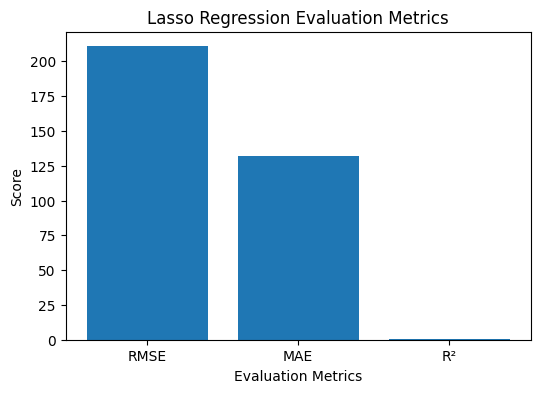

In [405]:
# Visualizing evaluation Metric Score chart
metrics = ['RMSE', 'MAE', 'R²']
scores = [
    np.sqrt(mean_squared_error(y_test, test_pred)),
    mean_absolute_error(y_test, test_pred),
    r2_score(y_test, test_pred)
]

plt.figure(figsize=(6,4))
plt.bar(metrics, scores)
plt.title("Lasso Regression Evaluation Metrics")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

#### 2. Cross- Validation & Hyperparameter Tuning

In [410]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=params,
    cv=5,
    scoring='r2'
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)
# Fit the Algorithm

# Predict on the model

Best Parameters: {'alpha': 1}
Best Cross Validation Score: 0.9459575589653163


##### Which hyperparameter optimization technique have you used and why?

GridSearch to evaluate different values of the alpha hyperparameter using 5-fold cross-validation. It selects the value that gives best model performamce.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

R2 score increased to 0.946 indicating better and more stable performance.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

- **R² (coefficient of determination):** the proportion of variance in Balance explained by the model. A high R² means the bank can trust the model's balance forecasts for portfolio-level interest revenue projections.
- **Adjusted R²:** penalizes R² for the number of features used, giving a fairer comparison across models with different feature counts (relevant since one-hot encoding expands the feature space).
- **MAE (Mean Absolute Error):** the average dollar error per customer prediction — directly interpretable as "on average, our balance forecast is off by \$X," useful for setting expectation bands on revenue forecasts.
- **RMSE (Root Mean Squared Error):** like MAE but penalizes large errors more heavily — important because a few very-wrong high-balance predictions could materially mis-estimate risk exposure or interest income.

Together, these metrics tell the bank not just whether the model is directionally right, but how much dollar-level error to expect, which is what turns a model into an operational forecasting or risk-flagging tool.

### ML Model - 3

In [412]:
# ML Model - 3 Implementation
model = Ridge(alpha=0.1)
model.fit(x_train,y_train)
# Fit the Algorithm

# Predict on the model

Ridge(alpha=0.1)

In [413]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [414]:
print('Train mean absolute error :- ',mean_absolute_error(y_train,train_pred))
print('Train mean squared error :- ',mean_squared_error(y_train,train_pred))
print('Train mean absolute percentage error :-',mean_absolute_percentage_error(y_train,train_pred))
print('Train R2 score:-',r2_score(y_train,train_pred))

print()
print('*'*30)
print()
print('Test mean absolute error :-',mean_absolute_error(y_test,test_pred))
print('Test mean squared error :-',mean_squared_error(y_test,test_pred))
print('Test mean absolute percentage error :-',mean_absolute_percentage_error(y_test,test_pred))
print('Test R2 score:-',r2_score(y_test,test_pred))

Train mean absolute error :-  83.68347416896451
Train mean squared error :-  10878.786535483925
Train mean absolute percentage error :- 1.3126608874664858e+17
Train R2 score:- 0.9509493384460799

******************************

Test mean absolute error :- 131.66731267827785
Test mean squared error :- 44328.41426068575
Test mean absolute percentage error :- 8.192919154056059e+16
Test R2 score:- 0.7346773252835133


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Text(0, 0.5, 'Score')

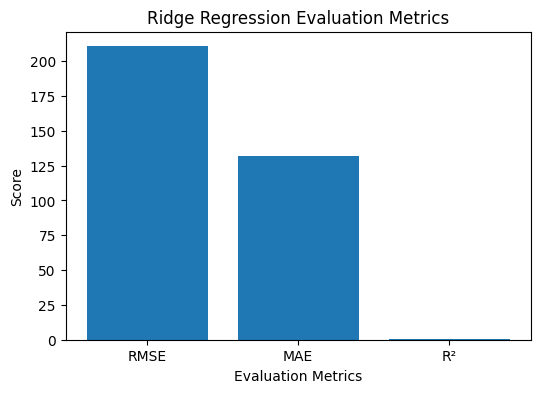

In [415]:
# Visualizing evaluation Metric Score chart
metrics = ['RMSE', 'MAE', 'R²']
scores = [
    np.sqrt(mean_squared_error(y_test, test_pred)),
    mean_absolute_error(y_test, test_pred),
    r2_score(y_test, test_pred)
]

plt.figure(figsize=(6,4))
plt.bar(metrics, scores)
plt.title("Ridge Regression Evaluation Metrics")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")

#### 2. Cross- Validation & Hyperparameter Tuning

In [416]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
params = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    estimator=Ridge(max_iter=10000),
    param_grid=params,
    cv=5,
    scoring='r2'
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)
# Fit the Algorithm

# Predict on the model

Best Parameters: {'alpha': 0.1}
Best Cross Validation Score: 0.9459530044391796


##### Which hyperparameter optimization technique have you used and why?

GridSearch to evaluate different values of the alpha hyperparameter using 5-fold cross-validation. It selects the value that gives best model performamce.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

R2 score increased to 0.946 indicating better and more stable performance.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

R², Adjusted R², MAE, and RMSE were used together. R²/Adjusted R² summarize overall explanatory power (good for comparing models and communicating "how good" the model is to stakeholders), while MAE and RMSE translate performance into dollar terms, which is what actually matters for revenue forecasting and risk-exposure decisions. No single metric was relied on alone, since R² can look good while individual errors are still large for high-balance customers — RMSE specifically guards against that.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Ridge Regression (tuned alpha = 0.1) is the final model.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

# **Conclusion**

This project built and compared three regression models — Linear Regression, Lasso, and Ridge — to predict customer credit card balance from demographic and financial attributes.

* The dataset (400 customers, 12 columns) required median/mean imputation for Income/Age and mode imputation for Student/Married (each missing 4–6% of values), plus one-hot encoding for categorical features.
* Limit and Rating are overwhelmingly the strongest predictors of Balance and are highly collinear with each other (r ≈ 0.997); Income is a moderate predictor; Student status has a visible secondary effect; Age, Education, Cards, Gender, Married, and Ethnicity show little to no predictive value.
* All three models reached a similar test R² of ~0.73–0.735, with Ridge Regression performing marginally best and being the most defensible choice given the Limit/Rating multicollinearity.
* There's a noticeable gap between train R² (~0.95) and test R² (~0.73) across all three models — a sign of some overfitting to the training set and/or a small test set (80 rows), and something to flag rather than gloss over. Cross-validation (~0.946) sitting between the two suggests the test set may just be a harder split; a larger dataset or repeated CV would help confirm this.
* MAPE was unusable due to zero-balance customers; MAE (~$132) and RMSE (~$211) are the more trustworthy dollar-denominated error metrics for this data.

Business value: the model gives the bank a data-driven way to forecast expected interest revenue, flag customers likely to carry high balances for proactive credit-limit or risk management, and identify segments (like students) that may warrant differentiated product offers — while the multicollinearity finding confirms that Limit and Rating should be treated as a single underwriting signal rather than two independent ones.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***